# ESP32 Data Logger — Notebook Starter

This notebook loads one or more CSV log files, normalizes timestamps, and gives you a few utilities for smoothing, resampling, and basic calibration.

> Tip: Run all cells once, then tweak the **Config** section and rerun as needed.

## Setup

In [1]:

# === Setup ===
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from logger_tools import ensure_datetime_index, resample_df, ema, moving_average, LinearCal, segment_by_marks

# Display options
pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


## Config

In [12]:

# === Config ===
# Point these at your logs. Example filenames: 2025-09-14_ride1.csv, 1694680995123.csv, etc.
DATA_DIR = r"C:\Users\benco\OneDrive\Documents\Arduino\esp32_data_logger\logs"  # change to your folder
GLOB = "*.csv"           # pattern for your logger files
LOCAL_TZ = "Australia/Perth"  # convert from UTC to your local time (optional)

# Choose your default resample rate for visualization (Hz). Set to None to skip.
RESAMPLE_HZ = 100

# Columns you'd like to plot by default (edit to match your sensors).
DEFAULT_PLOT_COLS = [
     "front_shock_mm_norm",
     "rear_shock_mm_norm",
    # "pot_raw", 
]

HIST_COLS = [
     "front_shock_mm_norm",
     "rear_shock_mm_norm",
    # "pot_raw", 
]

HIST_COLS_VEL = [
     "front_shock_mm_vel",
     "rear_shock_mm_vel",
    # "pot_raw", 
]

# If your logs contain a 'mark' column (0/1), you can split runs by marks later.
MARK_COLUMN = "mark"


## Load files

In [13]:
# === Load (force clock-style 'timestamp' parsing: mm:ss(.ms) or hh:mm:ss(.ms)) ===
import os, glob, pandas as pd, numpy as np

DATA_DIR = DATA_DIR  # from Config
GLOB     = GLOB
LOCAL_TZ = LOCAL_TZ  # unused here since we're using relative time

def clock_str_to_timedelta(s: pd.Series) -> pd.TimedeltaIndex:
    s = s.astype(str).str.strip().str.replace(",", ".", regex=False)  # tolerate commas as decimal sep
    parts = s.str.split(":", expand=True)

    if parts.shape[1] == 2:  # mm:ss(.ms)
        mm  = pd.to_numeric(parts[0], errors="coerce")
        sec = pd.to_numeric(parts[1], errors="coerce")
        total = mm * 60 + sec
    elif parts.shape[1] == 3:  # hh:mm:ss(.ms)
        hh  = pd.to_numeric(parts[0], errors="coerce")
        mm  = pd.to_numeric(parts[1], errors="coerce")
        sec = pd.to_numeric(parts[2], errors="coerce")
        total = hh * 3600 + mm * 60 + sec
    else:
        raise ValueError("Unexpected clock format; expected mm:ss(.ms) or hh:mm:ss(.ms)")

    first = total.dropna().iloc[0]
    rel_s = total - first
    return pd.to_timedelta(rel_s, unit="s")

files = sorted(glob.glob(os.path.join(DATA_DIR, GLOB)))
if not files:
    raise SystemExit(f"No files matched: {os.path.join(DATA_DIR, GLOB)}")

dfs = []
for fp in files:
    try:
        raw = pd.read_csv(fp, dtype=str, low_memory=False, on_bad_lines="skip")

        # Force use of the 'timestamp' column (case-insensitive); fall back to first column
        cols_lower = {c.lower(): c for c in raw.columns}
        ts_col = cols_lower.get("timestamp", raw.columns[0])

        idx = clock_str_to_timedelta(raw[ts_col])
        df  = raw.drop(columns=[ts_col])

        # Convert numeric-looking columns (leave text alone)
        for c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="ignore")

        df = df.set_index(idx).sort_index()
        dfs.append(df)
        print(f"Loaded {os.path.basename(fp)} with {len(df):,} rows; index=TimedeltaIndex")
    except Exception as e:
        print(f"Skipping {fp} -> {e}")

if not dfs:
    raise SystemExit("No files could be loaded. Check timestamp column/format.")

data = pd.concat(dfs).sort_index()

print(f"\nCombined rows: {len(data):,}")
print("Index type:", type(data.index).__name__)
print("Index sample:", data.index[:5])
print("\nHead(10):")
print(data.head(10).to_string())


Loaded Tunnel Vision.CSV with 145,152 rows; index=TimedeltaIndex

Combined rows: 145,152
Index type: TimedeltaIndex
Index sample: TimedeltaIndex([       '0 days 00:00:00', '0 days 00:00:00.010000', '0 days 00:00:00.020000', '0 days 00:00:00.030000',
                '0 days 00:00:00.040000'],
               dtype='timedelta64[ns]', freq=None)

Head(10):
                        front_shock_mm  front_shock_raw  rear_shock_mm  rear_shock_raw  mark
0 days 00:00:00              36.191494            735.0       5.789809           316.0     0
0 days 00:00:00.010000       35.992908            731.0       5.808917           317.0     0
0 days 00:00:00.020000       36.092197            733.0       5.808917           317.0     0
0 days 00:00:00.030000       36.141846            734.0       5.808917           317.0     0
0 days 00:00:00.040000       36.092197            733.0       5.770700           315.0     0
0 days 00:00:00.050000       35.943264            730.0       5.808917           317.0 

C:\Users\benco\AppData\Local\Temp\ipykernel_35244\2856732543.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


## Normalise

In [14]:
# === Normalize selected columns by subtracting min (offset) and dividing by user full-range ===
# Put this cell right after "Load files" so it operates on `data`.

import pandas as pd
import numpy as np

# --------- CONFIG ---------
# Map: column_name -> full_range_value (in the same units as the column)
NORMALIZE_RANGES = {
     "front_shock_mm": 170.0,
     "rear_shock_mm":  55.0,
    # "pot_raw":         4095.0,
}
OUTPUT_SUFFIX_ZEROED = "_zeroed"   # e.g. "front_travel_mm_zeroed"
OUTPUT_SUFFIX_NORM   = "_norm"     # e.g. "front_travel_mm_norm" (0..1 by your full-range)
CLIP_0_1             = True        # clip normalized values to [0,1]
ADD_ZEROED_COLUMN    = True        # also keep an offset-only (zeroed) version
# --------------------------

if "data" not in globals():
    raise RuntimeError("Expected 'data' from the Load cell. Run Load first.")

if not NORMALIZE_RANGES:
    raise ValueError("Please set NORMALIZE_RANGES = {'col': full_range, ...} before running this cell.")

# Work on the combined dataset
df = data.copy()

norm_report = []
for col, full_range in NORMALIZE_RANGES.items():
    if col not in df.columns:
        print(f"[skip] '{col}' not found in data columns.")
        continue
    try:
        if full_range is None or float(full_range) <= 0:
            print(f"[skip] '{col}' has invalid full_range={full_range}. Must be > 0.")
            continue
    except Exception:
        print(f"[skip] '{col}' full_range is not numeric: {full_range}")
        continue

    # Numeric conversion (non-numeric become NaN and are ignored in min/ops)
    s = pd.to_numeric(df[col], errors="coerce")

    if s.dropna().empty:
        print(f"[skip] '{col}' has no numeric data.")
        continue

    offset = float(s.min(skipna=True))  # detected zero = lowest observed value
    zeroed = s - offset                 # offset-corrected signal

    # Normalized by user-specified full-range (no auto-scaling)
    norm = zeroed / float(full_range)
    if CLIP_0_1:
        norm = norm.clip(0.0, 1.0)

    # Write columns
    if ADD_ZEROED_COLUMN:
        df[col + OUTPUT_SUFFIX_ZEROED] = zeroed
    df[col + OUTPUT_SUFFIX_NORM] = norm

    # Coverage & headroom report
    max_after_zero = float(zeroed.max(skipna=True)) if zeroed.dropna().size else np.nan
    coverage = max_after_zero / float(full_range) if np.isfinite(max_after_zero) else np.nan

    norm_report.append({
        "column": col,
        "offset(min)": offset,
        "full_range(config)": float(full_range),
        "max_after_zero": max_after_zero,
        "coverage_of_range": coverage,  # 1.0 means you hit the full-range
        "rows": int(s.dropna().shape[0]),
    })

# Commit back
data = df
print("Normalization complete. Added columns:")
for col in NORMALIZE_RANGES:
    if col in df.columns:
        if ADD_ZEROED_COLUMN:
            print(f"  - {col+OUTPUT_SUFFIX_ZEROED}")
        print(f"  - {col+OUTPUT_SUFFIX_NORM}")

# Summary table
if norm_report:
    rep = pd.DataFrame(norm_report).set_index("column")
    # Pretty print (avoid huge HTML tables if your Jupyter had display hiccups earlier)
    try:
        display(rep)
    except Exception:
        print(rep.to_string())
else:
    print("No columns were normalized (see messages above).")


Normalization complete. Added columns:
  - front_shock_mm_zeroed
  - front_shock_mm_norm
  - rear_shock_mm_zeroed
  - rear_shock_mm_norm


,offset(min),full_range(config),max_after_zero,coverage_of_range,rows
column,,,,,
front_shock_mm,21.148937,170.0,179.219868,1.054235,145152
rear_shock_mm,2.388535,55.0,42.878978,0.779618,145152


## Trim inactive sections

In [15]:
# === Trim inactive sections based on rolling change across columns ===
import numpy as np, pandas as pd

# Use resampled data if present; otherwise raw combined data
frame = globals().get("data_rs", globals().get("data"))
if frame is None:
    raise RuntimeError("No data found. Run the Load cell first.")
if not isinstance(frame.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
    raise TypeError("Expected a time-based index (Timedelta/Datetime).")

# ---------- CONFIG ----------
MONITOR_COLS = ["front_shock_mm"]        # e.g. ["front_travel_mm", "rear_travel_mm"]; None = all numeric cols
WINDOW       = "500ms"     # rolling window for change detection (e.g. "200ms", "1s")
DEFAULT_EPS  = 5         # 'significant' = max-min over WINDOW > threshold (units of each col)
PER_COL_EPS  = {"front_shock_mm":10 }          # per-column overrides, e.g. {"front_travel_mm": 1.0}
PADDING      = "200ms"     # keep a bit of context before/after active regions
MIN_SEGMENT  = "400ms"     # drop bursts shorter than this after padding
# ---------------------------

num_cols = frame.select_dtypes(include="number").columns.tolist()
cols = [c for c in (MONITOR_COLS or num_cols) if c in frame.columns]
if not cols:
    raise ValueError("No numeric columns to monitor; set MONITOR_COLS to your signal names.")

thr = pd.Series({c: PER_COL_EPS.get(c, DEFAULT_EPS) for c in cols})

# Rolling range (max - min) per column within WINDOW
roll_max   = frame[cols].rolling(WINDOW, min_periods=1).max()
roll_min   = frame[cols].rolling(WINDOW, min_periods=1).min()
roll_range = roll_max - roll_min

# Active where ANY monitored column exceeds its threshold
signif      = (roll_range > thr)
active_mask = signif.any(axis=1)

# Build padded active intervals
pad    = pd.to_timedelta(PADDING)
minseg = pd.to_timedelta(MIN_SEGMENT)

segments = []
if active_mask.any():
    block_id = (active_mask != active_mask.shift(fill_value=False)).cumsum()
    for _, g in active_mask.groupby(block_id):
        if not g.iloc[0]:  # skip False blocks
            continue
        s = g.index[0] - pad
        e = g.index[-1] + pad
        segments.append([s, e])

    # Merge overlapping/adjacent intervals
    segments.sort(key=lambda x: x[0])
    merged = []
    for s, e in segments:
        if not merged or s > merged[-1][1]:
            merged.append([s, e])
        else:
            merged[-1][1] = max(merged[-1][1], e)

    # Drop very short segments
    merged = [[s, e] for s, e in merged if (e - s) >= minseg]
else:
    merged = []

# Filter the dataframe and also provide per-segment cuts
if merged:
    keep = pd.Series(False, index=frame.index)
    for s, e in merged:
        keep |= (frame.index >= s) & (frame.index <= e)
    data_active = frame.loc[keep].copy()
    segments_active = [frame.loc[(frame.index >= s) & (frame.index <= e)].copy() for s, e in merged]
else:
    data_active = frame.iloc[0:0].copy()
    segments_active = []

print(f"Active segments kept: {len(merged)}")
for i, (s, e) in enumerate(merged, 1):
    print(f"  {i:02d}: {s} → {e}  (duration {(e - s)})")
print("Rows in original:", len(frame), " | Rows kept:", len(data_active))

# Optional: make the trimmed set the default for subsequent steps
# data_rs = data_active
data    = data_active


Active segments kept: 67
  01: 0 days 00:00:02.230000 → 0 days 00:00:04.460000  (duration 0 days 00:00:02.230000)
  02: 0 days 00:00:04.740000 → 0 days 00:00:05.750000  (duration 0 days 00:00:01.010000)
  03: 0 days 00:00:06.750000 → 0 days 00:00:29.920000  (duration 0 days 00:00:23.170000)
  04: 0 days 00:00:30.470000 → 0 days 00:00:32.920000  (duration 0 days 00:00:02.450000)
  05: 0 days 00:00:45.310000 → 0 days 00:01:06.920000  (duration 0 days 00:00:21.610000)
  06: 0 days 00:01:08.730000 → 0 days 00:01:09.920000  (duration 0 days 00:00:01.190000)
  07: 0 days 00:01:10.050000 → 0 days 00:01:10.920000  (duration 0 days 00:00:00.870000)
  08: 0 days 00:01:12.820000 → 0 days 00:02:13.920000  (duration 0 days 00:01:01.100000)
  09: 0 days 00:02:20.670000 → 0 days 00:02:21.920000  (duration 0 days 00:00:01.250000)
  10: 0 days 00:02:21.940000 → 0 days 00:02:23.720000  (duration 0 days 00:00:01.780000)
  11: 0 days 00:02:23.850000 → 0 days 00:02:24.710000  (duration 0 days 00:00:00.8600

## Quick-look plots

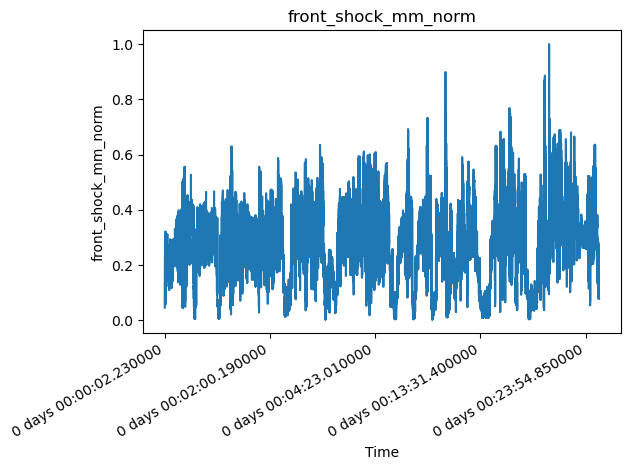

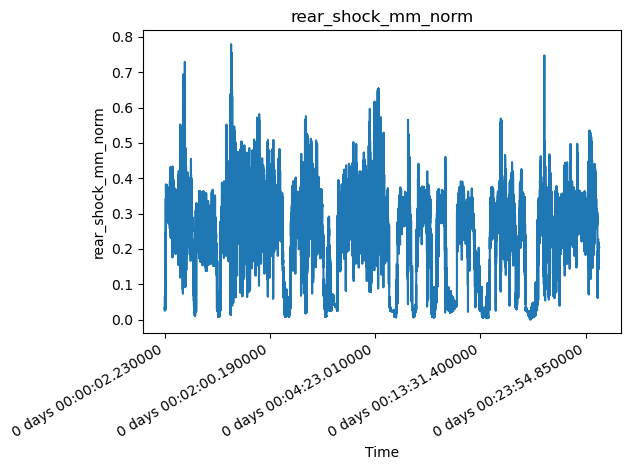

In [6]:
# Plot selected columns (each gets its own figure), with fallback if data_rs isn't defined
import matplotlib.pyplot as plt

frame = globals().get("data_rs", globals().get("data"))
if frame is None:
    raise RuntimeError("No data found. Run the Load cell first.")

# If you haven't set DEFAULT_PLOT_COLS, auto-pick up to 3 numeric columns
if not DEFAULT_PLOT_COLS:
    num_cols = frame.select_dtypes(include="number").columns.tolist()
    DEFAULT_PLOT_COLS = num_cols[:3]

plot_cols = [c for c in DEFAULT_PLOT_COLS if c in frame.columns]
if not plot_cols:
    print("Nothing to plot. Available columns:", list(frame.columns))
else:
    for col in plot_cols:
        plt.figure()
        frame[col].dropna().plot()
        plt.title(col)
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


## Interactive controls

In [7]:
# === Interactive zoom slider for time series ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Try to enable the interactive toolbar; harmless if it fails
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

def _first_frame():
    for name in ("data_active", "data_rs", "data"):
        obj = globals().get(name, None)
        if isinstance(obj, pd.DataFrame) and not obj.empty:
            return obj, name
    raise RuntimeError("No non-empty DataFrame found (data_active, data_rs, data).")

frame, source_name = _first_frame()

if not isinstance(frame.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
    raise TypeError("This widget expects a time-based index (DatetimeIndex or TimedeltaIndex).")

# Determine total time span in seconds and converter from slider seconds -> index
idx = frame.index
t_start = idx.min()
t_end   = idx.max()
total_sec = (t_end - t_start).total_seconds()

if isinstance(idx, pd.TimedeltaIndex):
    def to_index(sec): return pd.to_timedelta(sec, unit="s")
    slider_label = "Window (s from start)"
else:
    def to_index(sec): return t_start + pd.to_timedelta(sec, unit="s")
    slider_label = "Window (s from first timestamp)"

# Pick columns: DEFAULT_PLOT_COLS if set; else first 2 numeric columns
num_cols = frame.select_dtypes(include="number").columns.tolist()
default_cols = [c for c in globals().get("DEFAULT_PLOT_COLS", []) if c in num_cols] or num_cols[:2]
if not default_cols:
    raise ValueError("No numeric columns found to plot.")

# Widgets
rng = widgets.FloatRangeSlider(
    value=[0.0, min(10.0, max(1.0, total_sec))],
    min=0.0, max=max(1.0, total_sec), step=max(0.001, total_sec/10000),
    description=slider_label, continuous_update=False, readout_format=".3f", layout=widgets.Layout(width="95%")
)
cols_ms = widgets.SelectMultiple(
    options=num_cols, value=tuple(default_cols),
    description="Columns", layout=widgets.Layout(width="40%", height="140px")
)
status = widgets.HTML()

# Downsample for speed if lots of points
MAX_POINTS = 5000

out = widgets.Output()
ui = widgets.VBox([rng, widgets.HBox([cols_ms]), status])
display(ui, out)

def redraw(*_):
    with out:
        out.clear_output(wait=True)
        chosen = list(cols_ms.value)
        if not chosen:
            print("Select at least one column.")
            return
        s_sec, e_sec = rng.value
        start_i, end_i = to_index(s_sec), to_index(e_sec)
        view = frame.loc[start_i:end_i, chosen].dropna(how="all")
        if view.empty:
            print("No data in selected window.")
            return
        # Decimate for plotting speed
        step = max(1, len(view) // MAX_POINTS)
        view = view.iloc[::step]

        plt.figure()
        view.plot()  # single axes, multiple series
        plt.title(f"{chosen}  [{s_sec:.3f}s → {e_sec:.3f}s]  ({len(view)} pts)")
        plt.xlabel("Time")
        plt.ylabel("Value")
        plt.tight_layout()
        plt.show()

    status.value = f"<span style='opacity:0.7'>Source: <code>{source_name}</code>, window length: {(e_sec - s_sec):.3f}s</span>"

# Initial render + wiring
redraw()
rng.observe(redraw, names="value")
cols_ms.observe(redraw, names="value")


Output()

## Histograms of displacement

## Velocity and Acceleration

In [9]:
# --- Config ---
# Columns to process (zeroed displacement columns). If None, auto-detect numeric, non-time columns.
cols = None  # e.g., ["fork_mm_zeroed", "shock_mm_zeroed"]

# Sampling: either set sample_rate_hz OR ensure your index is DatetimeIndex OR there is a 'time_s' column.
sample_rate_hz = 100      # e.g., 1000.0
time_column_name = "time_s"  # set to None if deriving from DatetimeIndex

# Savitzky–Golay parameters
window_points = 11      # must be odd; typical 7–21
poly_order    = 3       # < window_points; typical 2–4

# Suffixes for outputs
VEL_SUFFIX = "_vel"
ACC_SUFFIX = "_acc"

# --- Implementation ---
import numpy as np
import pandas as pd

# Reuse your _first_frame() if defined; otherwise define it here
try:
    _first_frame
except NameError:
    def _first_frame():
        # Prefer trimmed; else resampled; else raw — but only if it exists and isn't empty
        for name in ("data_active", "data_rs", "data"):
            obj = globals().get(name, None)
            if isinstance(obj, pd.DataFrame) and not obj.empty:
                return obj, name
        raise RuntimeError("No non-empty DataFrame found (looked for data_active, data_rs, data).")

# Try SciPy; if missing, we’ll use a NumPy fallback
try:
    from scipy.signal import savgol_filter
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

def _infer_dt(df, sample_rate_hz=None, time_col="time_s"):
    """Infer dt (s) from explicit sample rate, a time column, or a DatetimeIndex."""
    if sample_rate_hz is not None:
        return 1.0 / float(sample_rate_hz)
    if time_col and time_col in df.columns:
        t = df[time_col].to_numpy()
        dt = np.median(np.diff(t))
        if not np.isfinite(dt) or dt <= 0:
            raise ValueError("Could not infer dt from time column.")
        return float(dt)
    if isinstance(df.index, pd.DatetimeIndex):
        dt = pd.Series(df.index).diff().dt.total_seconds().median()
        if not np.isfinite(dt) or dt <= 0:
            raise ValueError("Could not infer dt from DatetimeIndex.")
        return float(dt)
    raise ValueError("Cannot infer dt. Provide sample_rate_hz or a valid time column or DatetimeIndex.")

def _pick_cols(df, cols):
    """Pick numeric columns to process, excluding obvious time-like columns."""
    if cols is not None:
        return list(cols)
    drop_like = {"time", "timestamp", "date"}
    cands = []
    for c in df.select_dtypes(include=[np.number]).columns:
        lc = c.lower()
        if any(k in lc for k in drop_like):
            continue
        cands.append(c)
    if not cands:
        raise ValueError("No numeric columns found to process. Set 'cols' explicitly.")
    return cands

def _validate_params(window_points, poly_order):
    if window_points % 2 == 0:
        raise ValueError("window_points must be odd.")
    if poly_order >= window_points:
        raise ValueError("poly_order must be < window_points.")
    if poly_order < 1:
        raise ValueError("poly_order should be >= 1.")

def _savgol_numpy(y, window_points, poly_order, deriv, dt):
    """
    Minimal SG fallback using NumPy:
    - Build local polynomial basis (centered window),
    - Convolve with derivative coefficients,
    - Reflect-pad edges.
    """
    half = window_points // 2
    x = np.arange(-half, half + 1, dtype=float)
    A = np.vander(x, N=poly_order + 1, increasing=True)  # columns: x^0..x^p
    pinv = np.linalg.pinv(A)
    coeff = pinv[deriv, :] * np.math.factorial(deriv)     # derivative at x=0
    scale = (dt ** (-deriv))
    # Reflect-pad
    ypad = np.r_[y[1:half+1][::-1], y, y[-half-1:-1][::-1]]
    filt = np.convolve(ypad, coeff[::-1], mode="valid") * scale
    return filt

def estimate_va_from_zeroed(df,
                            cols=None,
                            sample_rate_hz=None,
                            time_col="time_s",
                            window_points=11,
                            poly_order=3,
                            vel_suffix=VEL_SUFFIX,
                            acc_suffix=ACC_SUFFIX):
    _validate_params(window_points, poly_order)
    dt = _infer_dt(df, sample_rate_hz=sample_rate_hz, time_col=time_col)
    target_cols = _pick_cols(df, cols)

    out = df.copy()
    # Handle NaNs gently
    data = out[target_cols].interpolate(limit_direction="both")

    for c in target_cols:
        y = data[c].to_numpy()
        if _HAVE_SCIPY:
            v = savgol_filter(y, window_points, poly_order, deriv=1, delta=dt, mode="interp")
            a = savgol_filter(y, window_points, poly_order, deriv=2, delta=dt, mode="interp")
        else:
            v = _savgol_numpy(y, window_points, poly_order, deriv=1, dt=dt)
            a = _savgol_numpy(y, window_points, poly_order, deriv=2, dt=dt)
        out[c + vel_suffix] = v
        out[c + acc_suffix] = a

    return out, {"dt": dt, "window_points": window_points, "poly_order": poly_order, "cols": target_cols}

# ---- Run on the currently active frame (data_active, else data_rs, else data) ----
df_src, src_name = _first_frame()

df_va, meta_va = estimate_va_from_zeroed(
    df_src,
    cols=cols,
    sample_rate_hz=sample_rate_hz,
    time_col=time_column_name,
    window_points=window_points,
    poly_order=poly_order,
)

# Expose result under a convenient global name, e.g. "data_va" if source was "data"
out_name = f"{src_name}_va"
globals()[out_name] = df_va
df_va  # also leave it as the last expression for notebook display

print(
    f"[VA] Source='{src_name}' → Output='{out_name}'. "
    f"Cols={meta_va['cols']}, dt={meta_va['dt']:.6f}s, "
    f"window={meta_va['window_points']}, order={meta_va['poly_order']}"
)


[VA] Source='data_active' → Output='data_active_va'. Cols=['front_shock_mm', 'front_shock_raw', 'rear_shock_mm', 'rear_shock_raw', 'mark', 'front_shock_mm_zeroed', 'front_shock_mm_norm', 'rear_shock_mm_zeroed', 'rear_shock_mm_norm'], dt=0.010000s, window=11, order=3


## Histograms of velocity

Using frame: data_active_va (41279 rows)


C:\Users\benco\AppData\Local\Temp\ipykernel_35244\2149589445.py:21: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  num_frame = frame.apply(pd.to_numeric, errors="ignore")


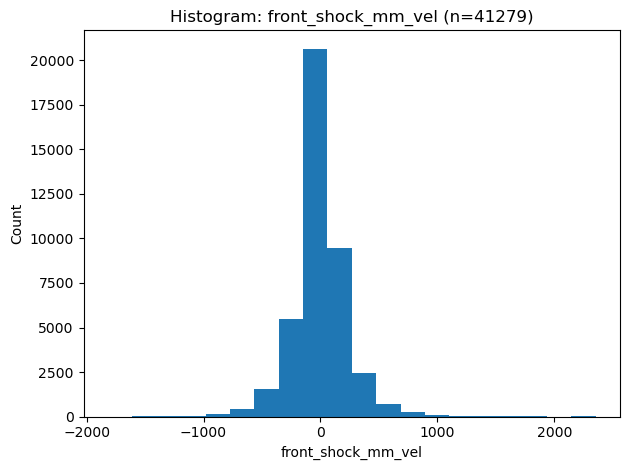

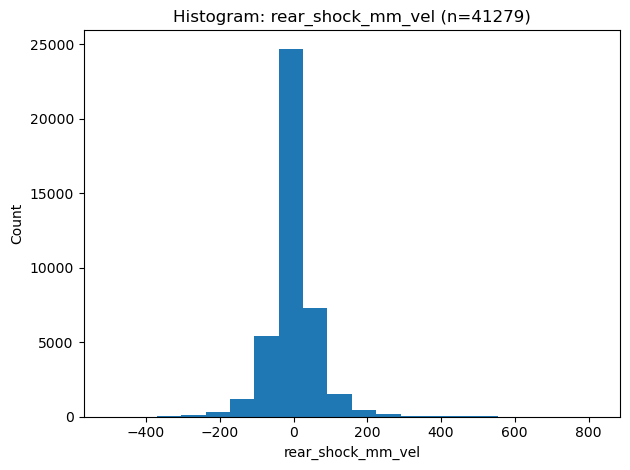

In [16]:
# === Histograms for selected columns (robust, 10 bins each) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _first_frame():
    # Prefer trimmed; else resampled; else raw — but only if it exists and isn't empty
    for name in ("data_active_va", "data_rs_va", "data_va"):
        obj = globals().get(name, None)
        if isinstance(obj, pd.DataFrame) and not obj.empty:
            return obj, name
    raise RuntimeError("No non-empty DataFrame found (looked for data_active, data_rs, data).")

frame, source_name = _first_frame()
print(f"Using frame: {source_name} ({len(frame)} rows)")

# Columns to plot:
# 1) Use HIST_COLS if set; else DEFAULT_PLOT_COLS; else auto-pick up to 3 numeric columns.
HIST_COLS = globals().get("HIST_COLS_VEL", None) or globals().get("DEFAULT_PLOT_COLS", [])
# Build a numeric-only view (without mutating original)
num_frame = frame.apply(pd.to_numeric, errors="ignore")
num_cols = num_frame.select_dtypes(include="number").columns.tolist()

if not HIST_COLS:
    HIST_COLS = num_cols[:3]

cols = [c for c in HIST_COLS if c in num_cols]
if not cols:
    raise ValueError(f"No numeric columns to histogram. Numeric available: {num_cols}")

for col in cols:
    s = pd.to_numeric(num_frame[col], errors="coerce").dropna()
    plt.figure()
    plt.hist(s.values, bins=20)  # use density=True for PDFs
    plt.title(f"Histogram: {col} (n={len(s)})")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


## Cumulative Probability

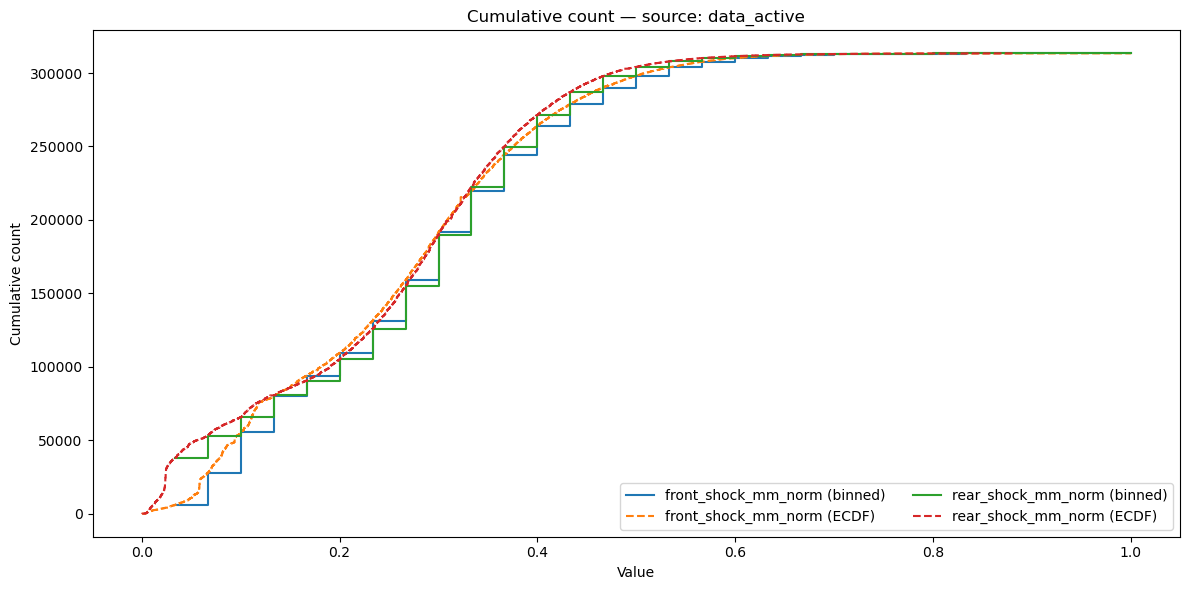

In [55]:
# === Multi-series cumulative plot (all columns on one graph) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _first_frame():
    for name in ("data_active", "data_rs", "data"):
        obj = globals().get(name, None)
        if isinstance(obj, pd.DataFrame) and not obj.empty:
            return obj, name
    raise RuntimeError("No non-empty DataFrame found (data_active, data_rs, data).")

frame, source_name = _first_frame()

# ---------- CONFIG ----------
CDF_COLS   = globals().get("CDF_COLS", None) or globals().get("DEFAULT_PLOT_COLS", [])
BINS       = 30            # number of bins for the shared grid
MODE       = "count"        # 'prob' => cumulative probability (0..1); 'count' => cumulative counts
ALSO_ECDF  = True          # overlay empirical CDF (bin-free) for each series
COMPLEMENT = False         # True -> plot 1 - CDF (survival)
FIGSIZE    = (12, 6)
# ----------------------------

# Choose numeric columns if not specified
num_cols = frame.select_dtypes(include="number").columns.tolist()
if not CDF_COLS:
    CDF_COLS = num_cols[:3]
cols = [c for c in CDF_COLS if c in num_cols]
if not cols:
    raise ValueError(f"No numeric columns found. Available numeric columns: {num_cols}")

# Collect series & global min/max
series = []
gmin, gmax = np.inf, -np.inf
for col in cols:
    s = pd.to_numeric(frame[col], errors="coerce").dropna().values
    if s.size < 2:
        print(f"Skipping {col}: not enough data.")
        continue
    series.append((col, s))
    gmin = min(gmin, float(np.min(s)))
    gmax = max(gmax, float(np.max(s)))

if not series:
    raise ValueError("No usable columns to plot.")

# Guard against zero-width range (constant data)
if not np.isfinite(gmin) or not np.isfinite(gmax) or gmax <= gmin:
    span = 1.0 if not np.isfinite(gmin) else max(1.0, abs(gmin) * 0.1)
    gmin, gmax = gmin - span, gmin + span

edges = np.linspace(gmin, gmax, int(BINS) + 1)
bin_widths = np.diff(edges)
x_step = edges[1:]  # step x-locations for 'post' stairs

fig, ax = plt.subplots(figsize=FIGSIZE)

for col, s in series:
    if MODE == "prob":
        pdf, _ = np.histogram(s, bins=edges, density=True)
        cdf = np.cumsum(pdf * bin_widths)  # integrate pdf over bins -> 0..1
        y = 1.0 - cdf if COMPLEMENT else cdf
        ax.step(x_step, y, where="post", label=f"{col} (binned)")
        if ALSO_ECDF:
            xs = np.sort(s)
            ys = np.arange(1, len(xs) + 1) / len(xs)
            if COMPLEMENT:
                ys = 1.0 - ys
            ax.step(xs, ys, where="post", linestyle="--", label=f"{col} (ECDF)")
    else:  # MODE == "count"
        counts, _ = np.histogram(s, bins=edges, density=False)
        ccum = np.cumsum(counts)
        y = (ccum[-1] - ccum) if COMPLEMENT else ccum
        ax.step(x_step, y, where="post", label=f"{col} (binned)")
        if ALSO_ECDF:
            xs = np.sort(s)
            ys = np.arange(1, len(xs) + 1)  # counts
            if COMPLEMENT:
                ys = ys[-1] - ys
            ax.step(xs, ys, where="post", linestyle="--", label=f"{col} (ECDF)")

ax.set_title(f"Cumulative {'probability' if MODE=='prob' else 'count'}"
             + (" (survival)" if COMPLEMENT else "")
             + f" — source: {source_name}")
ax.set_xlabel("Value")
ax.set_ylabel("Cumulative probability" if MODE == "prob" else "Cumulative count")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


## Frequency Domain

FFT using: data_active (resampled to 100.000 Hz; jitter 19528.74%)


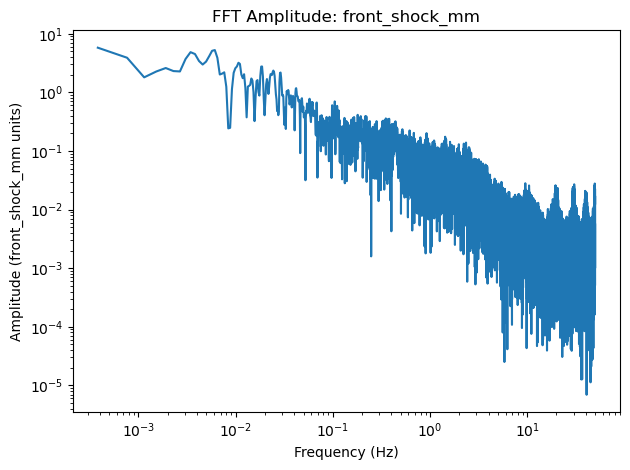

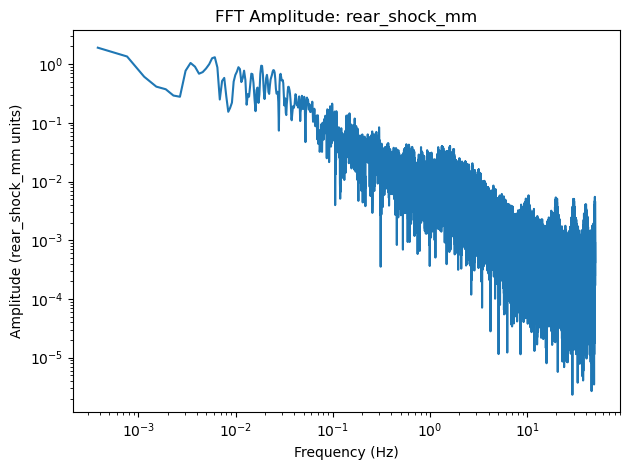

Frequency resolution ≈ 0.0004 Hz, Nyquist ≈ 50.000 Hz


In [15]:
# === FFT (amplitude spectrum) for selected columns ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _first_frame():
    for name in ("data_active", "data_rs", "data"):
        obj = globals().get(name, None)
        if isinstance(obj, pd.DataFrame) and not obj.empty:
            return obj, name
    raise RuntimeError("No non-empty DataFrame found (data_active, data_rs, data).")

frame, source_name = _first_frame()

# ---------- CONFIG ----------
FFT_COLS     = globals().get("FFT_COLS", None) or globals().get("DEFAULT_PLOT_COLS", [])
FORCE_HZ     = None       # e.g. 500 to force resampling to 500 Hz; None = infer from data
INTERP       = True       # interpolate after resampling (recommended)
LOG_X        = True      # set True for log-frequency x-axis
LOG_Y        = True      # set True for log-amplitude y-axis
# ---------------------------

# Pick numeric columns if none specified
num_cols = frame.select_dtypes(include="number").columns.tolist()
if not FFT_COLS:
    FFT_COLS = num_cols[:3]
cols = [c for c in FFT_COLS if c in num_cols]
if not cols:
    raise ValueError(f"No numeric columns to FFT. Numeric available: {num_cols}")

# Infer sampling period from index; optionally resample
if not isinstance(frame.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
    raise TypeError("FFT expects a time-based index (TimedeltaIndex or DatetimeIndex).")

# Calculate median dt (seconds)
dt = np.median(np.diff(frame.index.view('i8'))) / 1e9  # ns -> s
if dt <= 0:
    raise ValueError("Non-positive or invalid time step inferred.")
fs_infer = 1.0 / dt

# Jitter metric (% deviation from median)
dts = np.diff(frame.index.view('i8')) / 1e9
jitter_pct = 100.0 * np.std(dts) / (np.median(dts) if np.median(dts) else 1.0)

# Optionally resample to fixed rate
target_hz = FORCE_HZ if FORCE_HZ else fs_infer
if (FORCE_HZ is not None) or (jitter_pct > 2.0):  # resample if forced or noticeably irregular
    rule = pd.to_timedelta(1.0 / target_hz, unit="s")
    if INTERP:
        work = frame.resample(rule).mean().interpolate()
    else:
        work = frame.resample(rule).mean()
    fs = float(target_hz)
    src_note = f"{source_name} (resampled to {fs:.3f} Hz; jitter {jitter_pct:.2f}%)"
else:
    work = frame
    fs = float(fs_infer)
    src_note = f"{source_name} (native ~{fs:.3f} Hz; jitter {jitter_pct:.2f}%)"

print("FFT using:", src_note)

def next_pow2(n: int) -> int:
    return 1 if n <= 1 else 1 << (int(n - 1).bit_length())

for col in cols:
    s = pd.to_numeric(work[col], errors="coerce").dropna().values
    if len(s) < 8:
        print(f"Skipping {col}: too few samples ({len(s)})")
        continue

    # Detrend (remove mean)
    x = s - np.mean(s)

    # Windowing (Hann) + coherent gain correction for amplitude
    N = next_pow2(len(x))  # zero-pad to next power of two
    w = np.hanning(len(x))
    cg = w.mean() if w.size else 1.0  # coherent gain
    xw = np.zeros(N)
    xw[:len(x)] = x * w

    # Real FFT
    X = np.fft.rfft(xw)
    freqs = np.fft.rfftfreq(N, d=1.0/fs)

    # Amplitude spectrum (same units as input)
    # Scale: 2/(N*cg) for one-sided spectrum; DC and Nyquist not doubled
    amp = (2.0 / (N * cg)) * np.abs(X)
    if N % 2 == 0 and len(amp) > 1:
        amp[-1] *= 0.5  # Nyquist correction for even N
    if len(amp) > 0:
        amp[0] *= 0.5   # DC correction

    # Plot
    plt.figure()
    if LOG_X and LOG_Y:
        plt.loglog(freqs[1:], amp[1:])  # skip DC at 0 Hz on log axes
    elif LOG_X:
        plt.semilogx(freqs[1:], amp[1:])
    elif LOG_Y:
        plt.semilogy(freqs[1:], amp[1:])
    else:
        plt.plot(freqs, amp)
    plt.title(f"FFT Amplitude: {col}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel(f"Amplitude ({col} units)")
    plt.tight_layout()
    plt.show()

# Optional: print resolution / Nyquist
df = fs / next_pow2(len(work))
print(f"Frequency resolution ≈ {df:.4f} Hz, Nyquist ≈ {fs/2:.3f} Hz")


## Smoothing (EMA / Moving Average)

In [ ]:

# Example: apply EMA and plot
if DEFAULT_PLOT_COLS:
    col = next((c for c in DEFAULT_PLOT_COLS if c in data_rs.columns), None)
    if col:
        s = data_rs[col].dropna()
        s_ema = ema(s, alpha=0.2)          # tweak alpha in (0,1]
        s_ma  = moving_average(s, 11)      # tweak window size (samples)

        plt.figure()
        s.plot(label="raw")
        s_ema.plot(label="ema")
        plt.title(f"{col} (raw vs EMA)")
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

        plt.figure()
        s.plot(label="raw")
        s_ma.plot(label="ma")
        plt.title(f"{col} (raw vs Moving Average)")
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


## Simple linear calibration example

In [ ]:

# Suppose 'pot_raw' needs a linear map to mm. Adjust 'a' and 'b' to match your sensor calibration.
if "pot_raw" in data_rs.columns:
    cal = LinearCal(a=0.123, b=-10.0, units="mm")
    mm = cal.apply(data_rs["pot_raw"].astype(float))
    data_rs["pot_mm"] = mm

    plt.figure()
    data_rs["pot_mm"].dropna().plot()
    plt.title("pot_mm (calibrated)")
    plt.xlabel("Time")
    plt.ylabel("mm")
    plt.tight_layout()
    plt.show()


## Optional: Resample for visualization

In [5]:

if RESAMPLE_HZ:
    data_rs = resample_df(data, rate_hz=RESAMPLE_HZ, how="mean")
    print(f"Resampled to {RESAMPLE_HZ} Hz: {len(data_rs):,} rows")
else:
    data_rs = data.copy()


ValueError: len(index) != len(labels)

## Segment runs using `mark` events

In [ ]:

segments = segment_by_marks(data_rs, mark_col=MARK_COLUMN) if MARK_COLUMN in data_rs.columns else [data_rs]
print(f"Segments: {len(segments)}")
if segments:
    seg0 = segments[0]
    display(seg0.head())


## Export a cleaned CSV

In [ ]:

# Save out a cleaned/resampled file (optional)
OUT_CSV = os.path.join(DATA_DIR, "cleaned_resampled.csv")
data_rs.to_csv(OUT_CSV, index=True)
print("Wrote:", OUT_CSV)
